# Project 3: Representation Learning

## Objectives
Your goal in this project is to get comfortable in implementing k-means, PCA, and neural network. To complete this project, you should understand the following:

* How to use basic math and machine learning modules in python such as numpy
* How to fit a k-means algorithm *from scratch*
* How to perform PCA (principal component analysis) *from scratch* on MNIST dataset
* How to train a neural network *from scratch* on MNIST dataset
* How to evaluate the test results and visualize the outcome of these ML models

## Deliverable
* **Project report/writeup**: A `project3_report_lastname.pdf` file containing your **full solution**, including corresponding plots and results. Follow the `Project 3 - Report (Individual Submission)` link on Gradescope to upload this file. **The report must be self-contained**. 
  - For coding questions, you must include the relevant code snippets and execution results (outputs/plots, if applicable) directly in this PDF. Justifications such as "refer to the source code" are not acceptable. 
  - The report should also include a brief justification of your solution at a high level (e.g., using relevant explanations, equations, or diagrams) and a description of your code structure (e.g., a few sentences per function).



* **Source code**: A `project3_src_lastname1[_lastname2].ipynb` (or `.zip`) file with a working copy of your solutions compiled in a Jupyter notebook. Follow the `Project 3 - Source Code (Group Submission)` link to upload this file.


## Logistics

* You can work in groups of 1-2 students for each course project, and it's your responsibility to find a group (e.g. use Ed Discussion). 
* Every member of a group must complete and submit the project report/writeup individually. While the source code can be the same for all group members, the project report needs to be written independently by each person and, thus, should differ among team member and students more generally.
* One group member need to submit the source code. If you submit as a group, make sure to include your teammate in the group submission. Instructions for team submission can be found [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
* Grades will be provided based on the individual project report. The source code submission will not be graded, but the teaching staff may check the source files if they see the need for reproducing your results when going through your project report. 
* Failure to submit the source code will lead to a deduction of points from your total.

* ⚠️ <span style="color:red"> [For Project 3] </span> **Question Matching**: When uploading your PDF report to Gradescope, you must manually map your response pages to the corresponding questions. <span style="color:red">  Failure to properly match questions will result in point deductions.</span> 


## Task 3A: K-Means (30 points)
K-Means is an unsupervised ML algorithm that segments data into groups based on their similarities. In this part, we will implement k-means from scratch (using only numpy).

### Data Loader
We will use 2-dimensional data in this section. Specifically, the dataset are
2D points $[(x_1, x_2), (x_2, y_2), \dots, (x_n, y_n)]$ that form 5 distinct clusters.

In [1]:
# install seaborn for better visualization
!pip3 install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


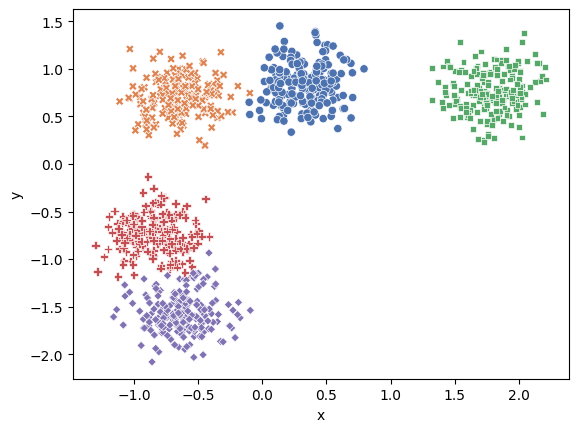

In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

num_samples = 1000
num_centers = 5

X_train, true_labels = make_blobs(
    n_samples=num_samples,
    centers=num_centers,
    random_state=80,
)
X_train = StandardScaler().fit_transform(X_train)
sns.scatterplot(
    x=[X[0] for X in X_train],
    y=[X[1] for X in X_train],
    hue=true_labels,
    style=true_labels,
    palette="deep",
    legend=None,
)

plt.xlabel("x")
plt.ylabel("y")
plt.show()

### K-Means Implementation
Now we are implementing the algorithm.

First, we define "similarity" between points. For our dataset, we will be using Euclidean distances.

1. **Implement a helper function**  that has two inputs: dataset, cur_point, and returns the Euclidean distance between cur_point and each point in the dataset.

In [ ]:
import numpy as np

def euclidean_dist(cur_point : np.ndarray, dataset : np.ndarray):
    '''
    cur_point has dimensions (m,), dataset has dimensions (n, m), and output will be of size (n,).
    '''
    dists = None
    #! YOUR CODE STARTS HERE
    #just the equation 
    dists = np.sqrt(np.sum((dataset - cur_point)**2, axis = 1))
    #! YOUR CODE ENDS HERE

    return dists

Now, we implement the actual K-Means algorithm. We first initialize K-Means with two parameters: number of clusters, and max number of iteractions, which you will use in the init function. 

1. **Implent the initialization functions** to accommodate four different seeding strategies: first k, random, max distance, and k-means++.
2. **Implement the fit function** which takes the dataset you created earlier as input. 

Finally, we can assign data points to the closest centroid in the provided predict function.

In [ ]:
#separated because of type errors!
from enum import Enum
import random
from numpy.random import uniform

class InitializationMethod(Enum):
    FirstK = 1
    Random = 2
    MaxDistance = 3
    KMeansPlusPlus = 4



In [ ]:

class KMeans:
    def __init__(self, n_clusters : int = 5, max_iter : int = 1000):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def initialize_and_fit(self,
                           initialization_method : InitializationMethod,
                           X_train : np.ndarray):
        # Initialize based on provided method choice.
        if initialization_method == InitializationMethod.FirstK:
            self.centroids = self.__initialize_first_k(X_train)
        elif initialization_method == InitializationMethod.Random:
            self.centroids = self.__initialize_random(X_train)
        elif initialization_method == InitializationMethod.MaxDistance:
            self.centroids = self.__initialize_max_distance(X_train)
        elif initialization_method == InitializationMethod.KMeansPlusPlus:
            self.centroids = self.__initialize_kmeanspp(X_train)

        # Some validation to be sure your methods are at least somewhat behaving.
        assert not self.centroids is None  # The centroids were set.
        assert len(self.centroids) == self.n_clusters  # n_clusters of them were chosen.

        # Fit to the given centroids.
        num_iterations_needed = self.__fit(X_train)
        return num_iterations_needed


    def __initialize_first_k(self, X_train : np.ndarray):
        """
        Initialize the centroids by selecting the first k points in X_train.
        """
        centroids = []

        #! YOUR CODE STARTS HERE
        centroids = X_train[:self.n_clusters].copy()
        #! YOUR CODE ENDS HERE

        return centroids

    def __initialize_random(self, X_train : np.ndarray):
        """
        Initialize the centroids by selecting k different points uniformly at
        random from X_train.
        """
        centroids = []

        #! YOUR CODE STARTS HERE
        centroids = X_train[np.random.choice(X_train.shape[0], size = self.n_clusters, replace=False)].copy()
        #! YOUR CODE ENDS HERE

        return centroids

    def __initialize_max_distance(self, X_train : np.ndarray):
        """
        Initialize the centroids by iteratively selecting the furthest point.
        First, a random datapoint is selected as the first centroid, and then
        at each step (until k have been selected) the point in X_train that is
        of maximum distance from any existing cluster center is selected.
        """
        # Pick a random point from train data for first centroid.
        centroids = [random.choice(X_train)]

        # Then choose the remaining points by selecting the point with maximum
        # euclidian distance to any current centroid.
        #
        #! YOUR CODE STARTS HERE
        # not necessary but speeds up calculation slightly maybe?
        # X_train_reduced = X_train.delete(X_train.index(centroids[0]))
        for i in range(self.n_clusters-1):
            dists = []
            #calculates the centroid that each data point is closest to
            dists = [euclidean_dist(cen, X_train) for cen in centroids]
            #distance to nearest centroid
            nearest = np.min(np.vstack(dists), axis=0)
            #index of point that is furthest from its closest centroid
            idx = np.argmax(nearest)
            centroids.append(X_train[idx].copy())
        #! YOUR CODE ENDS HERE

        return centroids

    def __initialize_kmeanspp(self, X_train : np.ndarray):
        """
        Initialize the centroids using the "k-means++" method, where a random
        datapoint is selected as the first, then the rest are initialized w/
        probabilities proportional to their distances to the first.
        """
        
        # Pick a random point from train data for first centroid.
        centroids = [random.choice(X_train)]

        # Then choose the remaining points as per kMeans++ algorithm.
        #
        #! YOUR CODE STARTS HERE
        for _ in range(self.n_clusters-1):
            #same as max for first two lines
            dists = [euclidean_dist(cen, X_train) for cen in centroids]
            nearest = np.min(np.vstack(dists), axis=0)
            #calculate probability based on square of distance to the nearest centroid. 
            #division to provide correct array to random choice
            probs = np.square(nearest)/sum(np.square(nearest))
            idx = np.random.choice(X_train.shape[0], p=probs)
            centroids.append(X_train[idx].copy())
        #! YOUR CODE ENDS HERE

        return centroids

    def __fit(self, X_train : np.ndarray):
        """
        Iterate, adjusting centroids until converged (new centroids are the same
        as previous centroids) or until passed max_iter.

        Returns the number of iterations needed for the choice of centroids to
        stabilize.
        """
        iteration_count = 0
        prev_centroids = None

        while np.not_equal(self.centroids, prev_centroids).any() and iteration_count < self.max_iter:
            #! YOUR CODE STARTS HERE
            prev_centroids = self.centroids.copy()
            labels = np.empty(X_train.shape[0], dtype=int)

            #
            for i in range(X_train.shape[0]):
                euclid = euclidean_dist(X_train[i], self.centroids)
                new_c = np.argmin(euclid)
                labels[i] = new_c
            
            for c in range(self.n_clusters):
                points_in_c = X_train[labels == c]
                if len(points_in_c) > 0:
                    self.centroids[c] = points_in_c.mean(axis=0)
                else:
                    self.centroids[c] = prev_centroids[c]
            
            #! YOUR CODE ENDS HERE
            iteration_count += 1

        return iteration_count

    def predict(self, X : np.ndarray):
        """
        Assign each data point to the nearest centroid.
        """
        centroids = []
        centroid_idxs = []
        for x in X:
            dists = euclidean_dist(x, self.centroids)
            centroid_idx = np.argmin(dists)
            centroids.append(self.centroids[centroid_idx])
            centroid_idxs.append(centroid_idx)

        return centroids, centroid_idxs

Now, **test and visualize your k-means algorithm** with various initializations. In the below given code, we separate the different true labels by marker styles (as previously), and we distinguish predicted labels by color.

*You should make sure all centroids ("+" signs) are in different predicted clusters. Hint: initialization is important for k-means, so this may not map to the cluster centroids of true labels for every run.*

The below code will generate 3 charts, each containing 4 sub-plots. 

**Include at least one of them in your report, and comment on your observations**.

- I am surprised that the Random clustering converges so successfully, given that the initialization does matter so much. I was expecting more clustering like the third graph shown. In all of the clustering results in which the bottom two groups are actually labelled as two groupss, there is one datapoint which is labelled wrong in every single graph. Those two clusters are very close together, but it is the only one in that group incorrectly marked. This shows some consistency despite different initialization. There is a clear difference between the "first-k" and the other three methods, but the k-means++ and max_distance work most effectively. I am interested in what types of datasets would show any kind of notable distinction between those two methods, given that the probability is based on the same distance used in max_distance. 

In [102]:
import matplotlib.pyplot as plt
import numpy as np

initialization_methods = [
    (InitializationMethod.FirstK, "First K"),
    (InitializationMethod.Random, "Random"),
    (InitializationMethod.MaxDistance, "Max Distance"),
    (InitializationMethod.KMeansPlusPlus, "k-Means++")
]


In [ ]:

def plot_predictions(model : KMeans, X : np.ndarray, y : np.ndarray):
    """Generates a single chart with subplots for multiple model prediction runs."""

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2x2 grid of subplots
    axes = axes.flatten()  # Flatten the axes array for easier indexing

    for i in range(len(initialization_methods)):
        method, name = initialization_methods[i]

        # Initialize with given method.
        model.initialize_and_fit(method, X_train)

        # View results
        class_centers, classification = model.predict(X_train)

        # Plot the ground truths
        sns.scatterplot(
            x=X,
            y=y,
            hue=classification,
            style=true_labels,
            palette="deep",
            legend=None,
            ax=axes[i]
        )
        # Plot the centroids
        axes[i].plot(
            [x for x, _ in class_centers],
            [y for _, y in class_centers],
            '+',
            markersize=20,
            c='black',
        )

        axes[i].set_title(name)

    plt.tight_layout()  # Adjust subplot params for a tight layout
    plt.show()

# Run k-means with each initialization method.
model = KMeans(n_clusters=num_centers)
for _ in range(3):
    plot_predictions(model, [X[0] for X in X_train], [X[1] for X in X_train])

The accuracy of these different methods can be seen above, but that's only the _end result_! As you can see in your code, each of these initialization methods is of varying complexity - so from each initialization state, how many steps does it take to complete initialization? 

**Include this graph in your report, and comment on the results.**

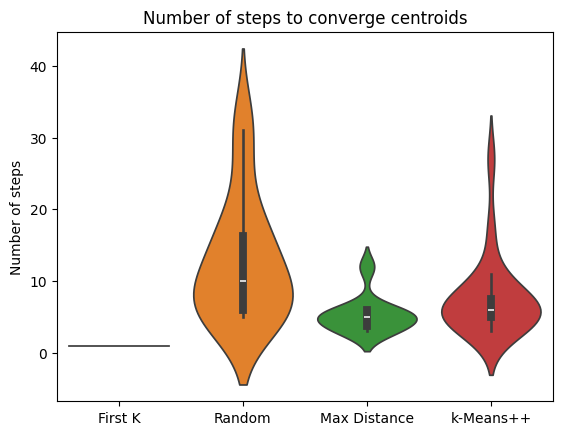

I am unsurprised that the random method and the k-means++ have a more dynamic set of iteration possibilities, given that they both rely on probability. Again, the max_distance seems to be the most reliable and most efficient. An interesting difference bteween k-means++ and the random methods is that the k-means++ has a small middle-half and a few outliers, while the random method has a much more expansive "normal" range. 

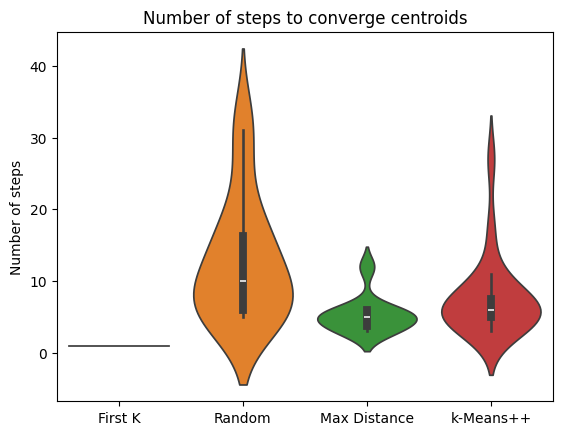

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

iterations = 20

# Run k-means with each initialization method.
model = KMeans(n_clusters=num_centers)
data = [] # Each entry in data will be Tuple<list of steps to converge, name of initialization method>
for method, name in initialization_methods:
    num_steps = []
    for _ in range(iterations):
        num_steps.append(model.initialize_and_fit(method, X_train))
    data.append((num_steps, name))

sns.violinplot([d[0] for d in data])
plt.xticks(np.arange(len(data)), labels=[d[1] for d in data])
plt.title("Number of steps to converge centroids")
plt.ylabel("Number of steps")
plt.show()

#### Questions

In practice, both k-Means++ and Max Distance are used. In what conditions might you prefer one of these methods over another? What are the drawbacks of each method?

*Hint: consider properties of our example. Do datasets in practice always have those properties?*

| Method | Pros | Prefered when | Cons |
| ------ | ---- | ------------- | ---- |
| k-means | less sensitive to outliers by virtue of probabilistic choice | if data is particularly noisy but not overlapping huge amounts | computationally complex and somewhat inefficient. if the data heavily overlaps (like in the bottom left of our original data, seen below this table) we might have centroids picked too close together, by (bad) luck | 
| max_distance | deterministic, making it consistent and less computationally costly | data is clearly clustered, without many outliers | deterministic, so not as good with complex data. worst case scenario is one far away point which gets its own cluster and reduces a centroid for the majority of the data | 

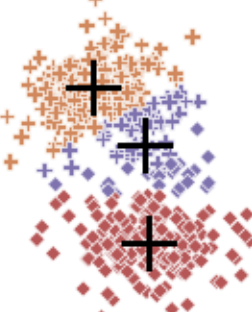

## Task 3B: Principal Component Analysis (30 points)

In this problem you will apply PCA for dimensionality reduction to the MNIST dataset.

Note that you must implement PCA directly with Numpy, you are not allowed to use the PCA class from scikit-learn or any other PCA/dimensionality reduction library.

### Load the dataset and visualize some examples

In [5]:
# Download dataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print('Loading and preprocessing data')
# Load data from https://www.openml.org/d/554
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False, data_home='data')
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.7)

Loading and preprocessing data


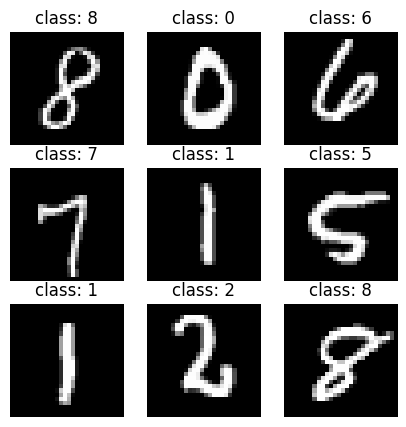

In [6]:
# Plot some random samples from training set
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(5, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'class: {y_train[i]}')
    ax.axis('off')

### A simple linear classifier

This class has been implemented for you. You don't need to change code here.

In [7]:
class LinearClassifier:
    """
    Simple linear classifier trained using full-batch gradient descent.
    - Maps n_features -> n_classes logits using a weight matrix W and bias vector b.
    - Applies softmax to the logits to get class probabilities that sum to 1.
    - In prediction, we take the class with the highest probability as our output class.
    """
    def __init__(self, n_features, classes=np.arange(10), eps=1e-4):
        self.classes = classes
        self.W = np.random.rand(n_features, len(classes)) / 30
        self.b = np.random.rand(len(classes)) / 30
        self.eps = eps
    
    def fit(self, X, y):
        assert len(X) == len(y)
        assert set(y) == set(self.classes)

        for i in range(200):
            # Forward pass
            z = X @ self.W + self.b

            # Softmax to convert logits to class probabilities
            exp_z = np.exp(z)
            softmax = exp_z / exp_z.sum(axis=1, keepdims=True)

            # Cross-entropy loss
            n = len(X)
            loss = -np.log(softmax[range(n), y]).sum() / n

            # Backward pass
            dL_dz = softmax
            dL_dz[range(n), y] -= 1
            dL_dz /= n

            dL_dW = X.T @ dL_dz
            dL_db = dL_dz.sum(axis=0)

            # Update weights
            self.W -= self.eps * dL_dW
            self.b -= self.eps * dL_db

            # Print classification accuracy
            if i % 50 == 0:
                predictions = np.argmax(z, axis=1)
                accuracy = (predictions == y).mean()
                print(f'iteration {i}: loss {loss:.4f}, accuracy {accuracy:.4f}')
        predictions = np.argmax(z, axis=1)
        accuracy = (predictions == y).mean()
        print(f'Final iteration {i}: loss {loss:.4f}, accuracy {accuracy:.4f}')
    
    def predict(self, X):
        z = X @ self.W + self.b
        return np.argmax(z, axis=1)


### Baseline

As a baseline, let's report the accuracy of a simple linear classifier trained with full-batch gradient descent. Instead of using all 28 x 28 = 784 pixels as input, we'll uniformly sample 27 pixels from the image and see what our accuracy is.

You should see something around ~57% train accuracy and ~57% test accuracy.

In [8]:
# Subsample every 30 pixels
X_train_subset = X_train[:, ::30]
print(f'Using {X_train_subset.shape[1]} features')

classifier = LinearClassifier(n_features=X_train_subset.shape[1])

# Center the data and store the means
feat_means = X_train_subset.mean(axis=0, keepdims=True)
X_train_subset = X_train_subset - feat_means
classifier.fit(X_train_subset, y_train)

Using 27 features
iteration 0: loss 6.1570, accuracy 0.0931
iteration 50: loss 1.4538, accuracy 0.5384
iteration 100: loss 1.3592, accuracy 0.5644
iteration 150: loss 1.3356, accuracy 0.5725
Final iteration 199: loss 1.3259, accuracy 0.5761


In [9]:
# Evaluate our test accuracy
X_test_subset = X_test[:, ::30]
preds = classifier.predict(X_test_subset - feat_means)
test_acc = (preds == y_test).mean()
print(f'Test accuracy: {test_acc:.4f}')

Test accuracy: 0.5758


### PCA for dimensionality reduction in classification

Can we use PCA to choose a more effective set of features?

In [ ]:
class PCA:
    def __init__(self, n_components):
        # Number of principal components to keep when we apply PCA
        assert n_components <= 784
        self.n_components = n_components

        self.feature_means = None
        self.U, self.S, self.Vt = None, None, None
        self.U_subset, self.S_subset, self.Vt_subset = None, None, None
    
    def fit(self, X):
        """
        Steps:
        - Center the data (compute, store, and subtract the mean of each feature)
        - Take the SVD of the centered data
        - Truncate the SVD by keeping only the first n_components (singular values)
        """
        #! YOUR CODE STARTS HERE
        #STEP 1: center the data
        #STEP a: compute and store mean of each feature. 
        self.feature_means = np.mean(X, axis = 0)
        #STEP b: subtract the mean of each feature
        X_centered = X - self.feature_means
        #STEP 2: take the SVD of the centered data
        self.U, self.S, self.Vt = np.linalg.svd(X_centered, full_matrices=False)
        #STEP 3: truncate the SVD
        self.U_subset = self.U[:, :self.n_components]
        self.S_subset = self.S[:self.n_components]
        self.Vt_subset = self.Vt[:self.n_components, :]
        #! YOUR CODE ENDS HERE

    def predict(self, X):
        """
        Steps:
        - Center the data (subtract the mean of each feature, stored in the fit)
        - Project the centered data onto the principal components

        Returns:
        - Projected data of shape (X.shape[0], n_components)
        """
        if self.feature_means is None:
            raise ValueError('fit the PCA model first')

        #! YOUR CODE STARTS HERE
        #STEP 1: center
        X_centered = X - self.feature_means
        return X_centered @ self.Vt_subset.T 
        #! YOUR CODE ENDS HERE

In [11]:
# Fit PCA
pca = PCA(27)
pca.fit(X_train)

Explained variance ratio with 27 components: 0.3143


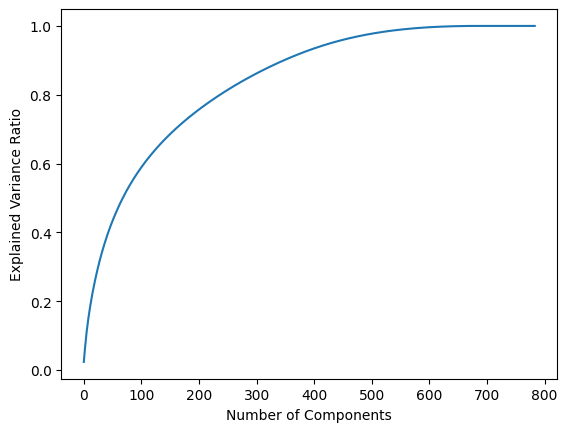

In [12]:
# Plot the explained variance ratio
S = pca.S
explained_var_ratio = S.cumsum() / S.sum()
plt.plot(explained_var_ratio)
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")

# Report the truncated feature ratio
print(f'Explained variance ratio with {pca.n_components} components: {explained_var_ratio[pca.n_components]:.4f}')

In [13]:
X_train_subset = pca.predict(X_train)
X_test_subset = pca.predict(X_test)

classifier = LinearClassifier(n_features=27)
classifier.fit(X_train_subset, y_train)

iteration 0: loss 19.7630, accuracy 0.1250
iteration 50: loss 0.6521, accuracy 0.8631
iteration 100: loss 0.4681, accuracy 0.8768
iteration 150: loss 0.4219, accuracy 0.8793
Final iteration 199: loss 0.4144, accuracy 0.8795


Evaluate our test accuracy with PCA. You are expected to achieve a higher accuracy >80%.

In [14]:
preds = classifier.predict(X_test_subset)
test_acc = (preds == y_test).mean()
print(f'Test accuracy: {test_acc:.4f}')

Test accuracy: 0.8789


### PCA for visualization
The following block of code will visualize the first 2 principal components. 

**Discuss what you see by comparing the clusters of different digits in the 2D space.**

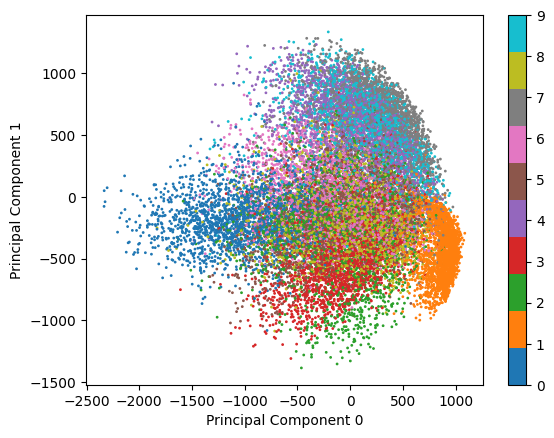](01graphretry.png)

With just the first two principal components, we can see the beginning of clustering within each of the labels. For example, labels 0 1 are somewhat separate. This is particularly true of label 1. Given that the orange color also stands out significantly, I tested other combinations of PCs and confirmed that the cluster in the (0, 1) graph is particularly well-defined. 

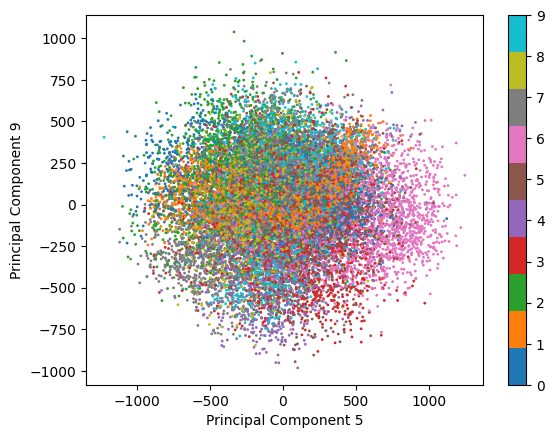

For example, while noticable, label 1 is clearly not clustered in the (5, 9) graph. These "starter" clusters can be used to show how reducing the number of principal components does not entirely eliminate the differences between the sets, even when we minimize it further, given that labels 0 and 1 are visible clusters solely using the first PC. On the other hand, labels 4, 7, and 9 overlap significantly, as well as 2, 3, and 8, though 2 and 3 have higher variance. Returning to the (5,9) graph, there are essentially no clusters, though label 6 (pink) does separate itself somewhat. 

![!\[(1,6)graph.png\](attachment:(1,6)graph.png)]((1,6)graph.png)

In order to separate 4, 7, and 9 (purple, gray, and light blue) we can observe the (1,6) graph, in which they are much more separate. This implies that feature 6 is a defining characteristic between these groupings. Graphs like this let us visualize the ways in which using more PCs, like our actual model uses, further differentiates these clusters. 

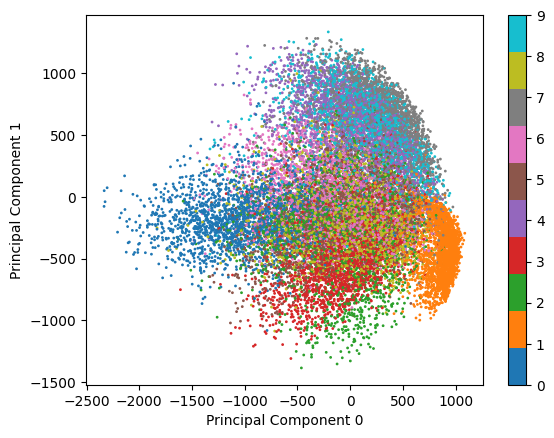

In [45]:
# Plot the first two PCs from the training set
plt.scatter(X_train_subset[:, 0], X_train_subset[:, 1], c=y_train, cmap='tab10', alpha=1.0, s=1)
plt.xlabel("Principal Component 0")
plt.ylabel("Principal Component 1")
plt.colorbar()

## Task 3C: Neural Network (40 points + 20 bonus points)

Your goal in this exercise is to classify
handwritten digits with neural networks. The training and test units, together with the
structure of a multilayer perceptron class are already provided in the starter code. Your task
is to code up the key lines that complete the **forward** and **backward** propagation functions.


**forward**: Recall that forward propagation corresponds to the prediction algorithm for neural nets. The
intermediate outputs for this method will be cached for backpropagation during the training phase.

**backward**: Backpropagation collects all the gradients necessary for training the neural network, which will be
used as input for the minibatch SGD algorithm GradientDescentOptimizer

In the next, you will need to implement the forward pass and backward pass of the linear layer. For the forward pass, it takes $x_l$ as input and outputs $x_{l+1}$.

$$x_{l+1} = w^\top x_{l} + b_{l}$$
For the backward pass, you will need to compute the backward gradients,



$$\frac{\partial \ell(x, y)}{\partial b}=?$$

$$ \frac{\partial \ell(x, y)}{\partial w}=? $$

$$\frac{\partial \ell(x, y)}{\partial x_{l}}=?$$

where $\ell$ is the loss function. 

### Task 3C.1: Forward and Backward Propogation (20pt)

**Implement the forward and backward pass of the linear layer.** 

Note - wherever you see the None value and #!YOUR CODE STARTS HERE, you are expected to fill in your code there for that variable. You can either overwrite the none value or redefine the same variable after the None assignment

Example:

```python
scores = None 

#!YOUR CODE STARTS HERE
scores = #your implementation here or you can overwrite the None value above

In [46]:
import numpy as np

class Layer(object):
    def __init__(self, shape, activ_func):
        "Implements a layer of a NN."
      
        self.w = np.random.uniform(-np.sqrt(2.0 / shape[0]),
                                   np.sqrt(2.0 / shape[0]),
                                   size=shape)
        self.b = np.zeros((1, shape[1]))

        # The activation function, for example, RELU, tanh, or sigmoid.
        self.activate = activ_func

        # The derivative of the activation function.
        self.d_activate = GRAD_DICT[activ_func]

    def forward(self, inputs):
        """Forward propagate the activation through the layer.
        
        Given the inputs (activation of previous layers),
        compute and save the activation of current layer,
        then return it as output.
        """

        ###################################Description begins#################
        # Forward pass

        # Use the linear and non-linear transformation to
        # compute the activation and cache it in a the field, self.a.

        # Functions you may use:
        # np.dot: numpy function to compute dot product of two matrix.
        # self.activate: the activation function of this layer,
        #                it takes in a matrix of scores (linear transformation)
        #                and compute the activations (non-linear transformation).
        # (plus the common arithmetic functions).

        # For all the numpy functions, use google and numpy manual for
        # more details and examples.        
        
        # Object fields you will use:
        # self.w:
        #     weight matrix, a matrix with shape (H_-1, H).
        #     H_-1 is the number of hidden units in previous layer
        #     H is the number of hidden units in this layer
        # self.b: bias, a matrix/vector with shape (1, H).
        # self.activate: the activation function of this layer.

        # Input:
        # inputs:
        #    a matrix with shape (N, H_-1),
        #    N is the number of data points.
        #    H_-1 is the number of hidden units in previous layer

        ###################################Description ends####################

        # Write code for the following variables according to their description.
        
        # The linear transformation.
        # scores:
        #     weighted sum of inputs plus bias, a matrix of shape (N, H).
        #     N is the number of data points.
        #     H is the number of hidden units in this layer.
        scores = None 
        
        #! YOUR CODE STARTS HERE
        scores = np.dot(inputs, self.w) + self.b
        #! YOUR CODE ENDS HERE
         

        # The non-linear transformation.
        # outputs:
        #     activations of this layer, a matrix of shape (N, H).
        #     N is the number of data points.
        #     H is the number of hidden units in this layer.
        activations = None 
        
        #! YOUR CODE STARTS HERE
        activations = self.activate(scores)
        #! YOUR CODE ENDS HERE

        # Cache the inputs and the activations (to be used by backprop).
        
        self.inputs = inputs
        self.a = activations
        outputs = activations
        return outputs

    def backward(self, d_outputs):
        """Backward propagate the gradient through this layer.
        
        Given the gradient w.r.t the output of this layer
        (d_outputs), compute and save the gradient w.r.t the
        weights (d_w) and bias (d_b) of this layer and
        return the gradient w.r.t the inputs (d_inputs).
        """
        ###################################Description begins#################
        # Backpropagation

        # Compute the derivatives of the loss w.r.t the weights and bias
        # given the derivatives of the loss w.r.t the outputs of this layer
        # using chain rule.

        # Naming convention: use d_var to store the
        # derivative of the loss w.r.t the variable.
        
        # Functions you may use:
        # np.dot (numpy.dot): numpy function to compute dot product of two matrix.
        # np.mean or np.sum (numpy.mean or numpy.sum):
        #     numpy function to compute the mean or sum of a matrix,
        #     use keywords argument 'axis' to compute the mean
        #     or sum along a particular axis, you might also
        #     found 'keepdims' argument useful.
        # self.d_activate:
        #     given the current activation (self.a) as input,
        #     compute the derivative of the activation function,
        #     See d_relu as an example.
        # (plus the common arithmetic functions).
        # np.transpose or m.T (m is an numpy array): transpose a matrix.
        
        
        # Object fields you will use:
        # self.w: weight matrix, a matrix with shape (H_-1, H).
        #         H_-1 is the number of hidden units in previous layer
        #         H is the number of hidden units in this layer
        # self.d_activate: compute derivative of the activation function.
        #                  See d_relu as an example.
        # d_outputs: the derivative of the loss w.r.t the outputs of
        #            this layer, a matrix of shape (N, H). N is the number of
        #            data points and H is the number of hidden units in this layer.
        # self.inputs: inputs to this layer, a matrix with shape (N, H_-1)
        #              N is the number of data points.
        #              H_-1 is the number of hidden units in previous layer.
        # self.a: activation of the hidden units of this layer, a matrix
        #         with shape (N, H)
        #         N is the number of data points.
        #         H is the number of hidden units in this layer.

        ###################################Description ends####################
        
        
        #  Write code for the following variables according to their description.

        # d_scores:
        #     Derivatives of the loss w.r.t the scores (the result from linear transformation).
        #     A matrix of shape (N, H)
        #     N is the number of data points.
        #     H is the number of hidden units in this layer.
        d_scores = None 
        
        #! YOUR CODE STARTS HERE
        d_scores = d_outputs * self.d_activate(self.a)
        #! YOUR CODE ENDS HERE

        # self.d_b:
        #     Derivatives of the loss w.r.t the bias, averaged over all data points.
        #     A matrix of shape (1, H)
        #     H is the number of hidden units in this layer.

        self.d_b = None 
        
        #! YOUR CODE STARTS HERE
        self.d_b = np.sum(d_scores, axis=0, keepdims=True)
        #! YOUR CODE ENDS HERE

        # self.d_w:
        #     Derivatives of the loss w.r.t the weight matrix, averaged over all data points.
        #     A matrix of shape (H_-1, H)
        #     H_-1 is the number of hidden units in previous layer
        #     H is the number of hidden units in this layer.        
        self.d_w = None 
        
        #! YOUR CODE STARTS HERE
        self.d_w = np.dot(self.inputs.T, d_scores)
        #! YOUR CODE ENDS HERE

        # d_inputs:
        #     Derivatives of the loss w.r.t the previous layer's activations/outputs.
        #     A matrix of shape (N, H_-1)
        #     N is the number of data points.
        #     H_-1 is the number of hidden units in the previous layer.
        d_inputs = None 
        
        #! YOUR CODE STARTS HERE
        d_inputs = np.dot(d_scores, self.w.T)
        #! YOUR CODE ENDS HERE
        
		# Compute the average value of the gradients, since
        # we are minimizing the average loss. 
        self.d_b /= d_scores.shape[0]
        self.d_w /= d_scores.shape[0]
        
        return d_inputs

You have successfully completed task 3A. Please run the code to define the Multi-Layer Perceptron (MLP).

In [47]:
import numpy as np
    
#########################
#  Multilayer Perceptron
#########################

class MLP(object):
    def __init__(self, input_dim, output_dim, sizes, activ_funcs):
        """Multilayer perceptron for multi-class classification.

        The object holds a list of layer objects, each one
        implements a layer in the network, the specification
        of each layer is decided by input_dim, output_dim,
        sizes and activ_funcs. Note that an output layer
        (linear) and loss function (softmax and
        cross-entropy) would be automatically added to the MLP.

        Input: 
          input_dim: dimension of input.
          output_dim: dimension of output (number of labels).
          sizes: a list of integers specifying the number of
            hidden units on each layer.
          activ_funcs: a list of function objects specifying
            the activation function of each layer.

        """
        # Last layer is linear and loss is mean_cross_entropy_softmax
        self.sizes = [input_dim] + sizes[:] + [output_dim]
        self.activ_funcs = activ_funcs[:] + [linear]
        self.shapes = []
        for i in range(len(self.sizes)-1):
            self.shapes.append((self.sizes[i], self.sizes[i+1]))

        self.layers = []
        for i, shape in enumerate(self.shapes):
            self.layers.append(Layer(shape, self.activ_funcs[i]))

    def forwardprop(self, data, labels=None):
        """Forward propagate the activations through the network.

        Iteratively propagate the activations (starting from
        input data) through each layer, and output a
        probability distribution among labels (probs), and
        if labels are given, also compute the loss. 
        """
        inputs = data
        for layer in self.layers:
            outputs = layer.forward(inputs)
            inputs = outputs
            
        probs = softmax(outputs)
        if labels is not None:
            return probs, self.loss(outputs, labels)
        else:
            return probs, None

    def backprop(self, labels):
        """Backward propagate the gradients/derivatives through the network.
        
        Iteratively propagate the gradients/derivatives (starting from
        outputs) through each layer, and save gradients/derivatives of
        each parameter (weights or bias) in the layer.
        """
        d_outputs = self.d_loss(self.layers[-1].a, labels)
        for layer in self.layers[::-1]:
            d_inputs = layer.backward(d_outputs)
            d_outputs = d_inputs

    def loss(self, outputs, labels):
        "Compute the cross entropy softmax loss."
        return mean_cross_entropy_softmax(outputs, labels)

    def d_loss(self, outputs, labels):
        "Compute derivatives of the cross entropy softmax loss w.r.t the outputs."
        return d_mean_cross_entropy_softmax(outputs, labels)
        
    def predict(self, data):
        "Predict the labels of the data."
        probs, _ = self.forwardprop(data)
        return np.argmax(probs, axis=1)


class GradientDescentOptimizer(object):
    def __init__(self, learning_rate, decay_steps=1000,
                 decay_rate=1.0):
        "Gradient descent with staircase exponential decay."
        self.learning_rate = learning_rate
        self.steps = 0.0
        self.decay_steps = decay_steps
        self.decay_rate = decay_rate
        
    def update(self, model):
        "Update model parameters."
        for layer in model.layers:
            layer.w -= layer.d_w * self.learning_rate
            layer.b -= layer.d_b * self.learning_rate
        self.steps += 1
        if (self.steps + 1) % self.decay_steps == 0:
            self.learning_rate *= self.decay_rate


# Utility functions.
def sigmoid(x): 
    return 1/(1+np.exp(-x))   

def d_sigmoid(a=None, x=None):
    if a is not None:
        return a * (1 - a)
    else:
        return d_sigmoid(a=sigmoid(x))

def relu(x):
    "The rectified linear activation function."
    return np.clip(x, 0.0, None)

def d_relu(a=None, x=None):
    "Compute the derivative of RELU given activation (a) or input (x)."
    if a is not None:    
        d = np.zeros_like(a)
        d[np.where(a > 0.0)] = 1.0
        return d
    else:
        return d_relu(a=relu(x))

def tanh(x):
    "The tanh activation function."
    return np.tanh(x)

def d_tanh(a=None, x=None):
    "The derivative of the tanh function."
    if a is not None:
        return 1 - a ** 2
    else:
        return d_tanh(a=tanh(x))

def linear(x):
    return x

def d_linear(a=None, x=None):
    return 1.0

def softmax(x):
    shifted_x = x - np.max(x, axis=1, keepdims=True)
    f = np.exp(shifted_x)
    p = f / np.sum(f, axis=1, keepdims=True)
    return p
    
def mean_cross_entropy(outputs, labels):
    n = labels.shape[0]
    return - np.sum(labels * np.log(outputs)) / n

def mean_cross_entropy_softmax(logits, labels):
    return mean_cross_entropy(softmax(logits), labels)

def d_mean_cross_entropy_softmax(logits, labels):
    return softmax(logits) - labels


# Mapping from activation functions to its derivatives.
GRAD_DICT = {linear: d_linear, sigmoid: d_sigmoid, tanh: d_tanh, relu: d_relu}


Now that we have defined the MLP, let's prepare the data. 

We will still use the MNIST dataset, but we will preprocess the data differently for the neural network.

We will normalize the pixel values to be between 0 and 1 and use one-hot encoding for the labels.

In [48]:
# Download dataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print('Loading and preprocessing data')
# Load data from https://www.openml.org/d/554
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False, data_home='data')
X = X / 255.0
y = y.astype(int)

(train_data, test_data, train_labels, test_labels) = train_test_split(X, y, random_state=0, test_size=0.7)

def create_one_hot_labels(labels, dim=10):
    one_hot_labels = np.zeros((labels.shape[0], dim))
    for i in range(labels.shape[0]):
        one_hot_labels[i][labels[i]] = 1
    return one_hot_labels

# Convert labels from integers to one-hot encodings
test_labels = create_one_hot_labels(test_labels)
train_labels = create_one_hot_labels(train_labels)
n_train = train_data.shape[0]

Loading and preprocessing data


### Task 3C.2 Training the Neural Network (10pt)

1. Report the training loss, training accuracy, test loss, and test accuracy for the default network architecture.

    ` MLP(784, 10, [16], [sigmoid])`

====================Epoch 24====================

Train loss 0.7814373664102557 accuracy 0.8357619047619048

====================Training finished====================

Test loss 0.768769645707442 accuracy 0.8386938775510204

In [49]:
# Function to train model and return loss & accuracy
def train_and_eval(model, optimizer=None, n_epochs=25, batch_size=100):    
    if optimizer is None:
        optimizer = GradientDescentOptimizer(0.01)
    train_loss_list = []
    train_accuracy_list = []

    for i in range(n_epochs):
        sum_loss = 0.0
        for j in range((n_train - 1) // batch_size + 1):
            batch_data = train_data[j * batch_size:(j + 1) * batch_size]
            batch_labels = train_labels[j * batch_size:(j + 1) * batch_size]
            
            _, loss = model.forwardprop(batch_data, batch_labels)
            if np.isnan(loss):
                continue
            
            sum_loss += loss
            model.backprop(batch_labels)
            optimizer.update(model)

        train_loss = sum_loss / (j + 1)
        train_accuracy = (np.sum(model.predict(train_data) == np.argmax(train_labels, axis=1)) / 
                          np.float64(train_labels.shape[0]))
        
        train_loss_list.append(train_loss)
        train_accuracy_list.append(train_accuracy)
        print('=' * 20 + ('Epoch %d' % i) + '=' * 20)
        print('Train loss %s accuracy %s' % (train_loss, train_accuracy))
    
    _, test_loss = model.forwardprop(test_data, test_labels)
    test_accuracy = (np.sum(model.predict(test_data) == np.argmax(test_labels, axis=1)) / 
                      np.float64(test_labels.shape[0]))
    print('=' * 20 + 'Training finished' + '=' * 20 + '\n')
    print ('Test loss %s accuracy %s\n' %
            (test_loss, test_accuracy))

    return train_loss_list, train_accuracy_list, test_loss, test_accuracy

In [50]:
# Initialize model
print('Initializing neural network')
mlp_gd = MLP(784, 10, [16], [sigmoid])

# For plots, we are tracking a subset of test data points before and after training
selected = np.random.randint(test_data.shape[0], size=100)
true_labels = np.argmax(test_labels[selected], axis=1)
preds_init = mlp_gd.predict(test_data[selected])

print('Start training')
train_loss_gd, train_acc_gd, test_loss_gd, test_acc_gd = train_and_eval(mlp_gd)

preds_trained = mlp_gd.predict(test_data[selected])

Initializing neural network
Start training
====================Epoch 0====================
Train loss 2.2813846191353546 accuracy 0.2604761904761905
====================Epoch 1====================
Train loss 2.1656030764464105 accuracy 0.5638095238095238
====================Epoch 2====================
Train loss 2.070500680920028 accuracy 0.6327619047619047
====================Epoch 3====================
Train loss 1.9743332857051967 accuracy 0.6555238095238095
====================Epoch 4====================
Train loss 1.876565871758943 accuracy 0.6667142857142857
====================Epoch 5====================
Train loss 1.7787834912766536 accuracy 0.6755714285714286
====================Epoch 6====================
Train loss 1.6831002364119263 accuracy 0.6866666666666666
====================Epoch 7====================
Train loss 1.5914125853364138 accuracy 0.6996190476190476
====================Epoch 8====================
Train loss 1.5050479731481698 accuracy 0.7104761904761905
=====

Plot the training loss and accuracy as a function of the number of epochs for debugging.

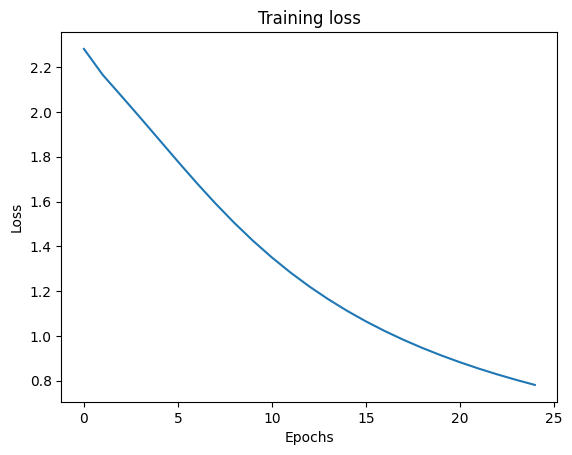

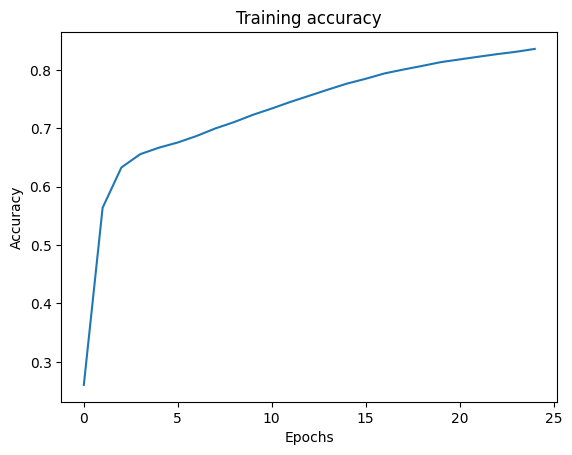

In [51]:
import matplotlib.pyplot as plt

# Plot the training loss and accuracy separately.
n_epochs = len(train_loss_gd)
plt.plot(range(n_epochs), train_loss_gd, label='train loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss')
plt.show()

plt.plot(range(n_epochs), train_acc_gd, label='train accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training accuracy')
plt.show()

## Questions:
1. Briefly comment/discuss your implementation of the `Layer` class 

One issue I dealt with was making sure not to average the bias and weights twice, because the code already included division at the end of backwarads propogation function. When I was just writing the code as described, I included the average in the single line defining the two matrices, but making sure to read and understand the whole function meant that I removed those parts. This averaging makes the gradient consistent regardless of the size of the dataset, so more data (which is usually helpful for training) will not make each step in the gradient too large. 


1. Report the training loss, training accuracy, test loss, and test accuracy for the default network architecture. Comment on the results.
    
As stated above, the training loss after 25 epochs was .781 and the accuracy was 83.6%. The test loss was .769 and the accuracy was 83.9%. The similarity in test and training accuracy implies that the model is not overfit to the training data. The fact that the test loss is lower than the training loss is slightly strange, but the similarity implies that the model is well fit for both the training data and test data, or that they are distributed similarly. The graph of accuracy also shows that with very little training (after the first epoch), the model already went from 10% accuracy (guessing the same value for every datapoint, where there are 10 options) to 26% accuracy. With just one more epoch, we reach over 50% accuracy. While there are clearly diminishing returns, it is fun to see how quickly the model can improve. On the other hand, the loss graph shows that it is neither converging nor significantly changing slope, with more epochs. I am interested in whether it ever would, and how long / how much more data that would take.

### Task 3C.3 Visualizing the Predictions and Weights (5pt)

In your solution, include a plot of the test samples using the following code.

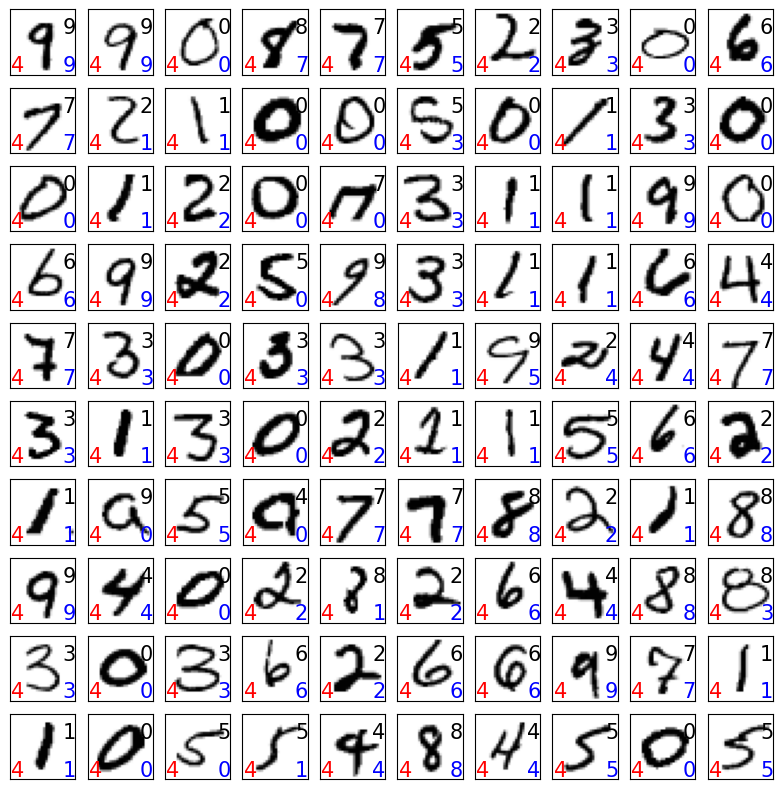

In [52]:
# plot sample test images together with their groundtruth (black), predicted labels before training (red) and predicted labels after training (blue).

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
fig.subplots_adjust(wspace=0)
for a, image, true_label, pred_init, pred_trained in zip(
        axes.flatten(), test_data[selected],
        true_labels, preds_init, preds_trained):
    a.imshow(image.reshape(28, 28), cmap='gray_r')
    a.text(22, 10, str(true_label), color="black", size=15)
    a.text(22, 26, str(pred_trained), color="blue", size=15)
    a.text(0, 26, str(pred_init), color="red", size=15)

    a.set_xticks(())
    a.set_yticks(())

plt.show()

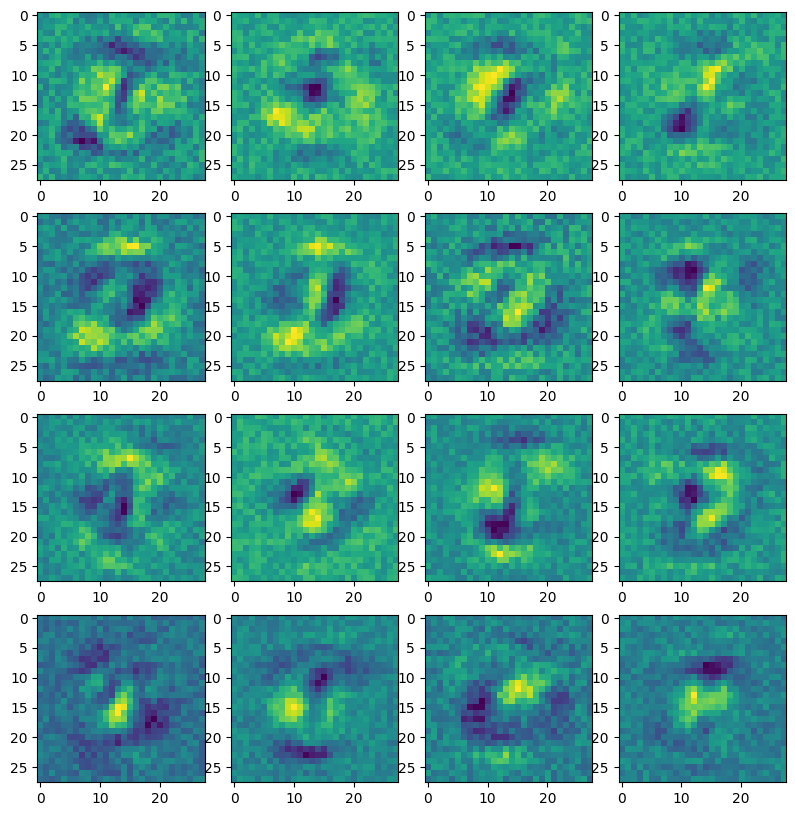

In [61]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.subplots_adjust(wspace=0)
idx = 0
for a in axes.flatten():
    a.imshow(mlp_gd.layers[0].w[:, idx].reshape((28, 28)))
    idx +=1
plt.show()

## Questions:
1. In your report, include a plot of your test-samples. Also include a visualization of the weights of the first layer in the MLP, along with a detailed explanation of the code and a brief summary of any observed patterns and understandings.

In the two visualizations above, we can compare the inaccuracies in labelling with the first layer of activations. For example, consider the following two images:

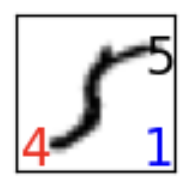 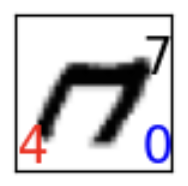 

In these two incorrect outcomes, we can see similar shapes to what the guess was, namely, the straight line in the center and the lack of drawing in the center. These can be related to two of the first activation layer weights: 

<img src="lookingfor0.png" width="200"> <img src="lookingforline.png" width="200"> 

The first is an example of where the model might look for less value in the middle of the image (i.e. a loop), and the second shows a line in the center. While they are not exact matches, it is clear how the mistakes might have been made. 

In ```forwardprop``` you use the forward layer update that was coded earlier. ```backprop``` does similarly. 

Note that the visualization of the weights directly accesses the weights that we propogate through the layers and update when working backward, in ```backprop```. These act as a first feature detector, which explains why we can begin to see shapes in the images, as explained above. When we move to the next layer, the feature detector is instead looking at how well those 0 layer shapes align with the written number. 

There is actually a great 3blue1brown video detailing this exact process, if you are ever looking for more visualizations. 

### Task 3C.4: Hyperparameter tuning (5pt)

Modify only the network architecture (e.g. number of hidden units, activation functions, etc.) to improve the test accuracy, and provide a summary of your findings.

Theres no strict way to do this but we want to see that you did a meaningful exploration of different architectures and hyperparameters.


In [ ]:
# Initialize model
print('Initializing neural network')
model = None 

# instantiate your MLP model and play around with different activations, hidden layer sizes etc. 
#! YOUR CODE STARTS HERE
experiments = [
    ("1x16 sigmoid (baseline)",  [16],          [sigmoid]),
    ("1x64 sigmoid",             [64],          [sigmoid]),
    ("1x64 tanh",                [64],          [tanh]),
    ("1x64 relu",                [64],          [relu]),
    ("1x128 relu",               [128],         [relu]),
    ("2x128-64 relu",            [128, 64],     [relu, relu]),
    ("2x256-128 relu",           [256, 128],    [relu, relu]),
    ("3x256-128-64 relu",        [256,128, 64], [relu, relu, relu]),
]

results = []

best = (-1, None)
for name, hiddens, activations in experiments:
    model = MLP(784, 10, hiddens, activations)
    train_loss_list, train_accuracy_list, test_loss, test_accuracy = train_and_eval(model)

    results.append((name, hiddens, [a.__name__ for a in activations], test_accuracy))
    print(f"{name:22s}  hidden={hiddens}  act={[a.__name__ for a in activations]}  test_acc={test_accuracy:.4f}")

    if test_accuracy > best[0]:
        best = (test_accuracy, name)

print("\nBest:", best[1], "with test_acc=", best[0])
#! YOUR CODE ENDS HERE

# Train the model
train_loss_list, train_accuracy_list, test_loss, test_accuracy = train_and_eval(model)

Initializing neural network
====================Epoch 0====================
Train loss 2.271428090476319 accuracy 0.36223809523809525
====================Epoch 1====================
Train loss 2.165336048006704 accuracy 0.48942857142857144
====================Epoch 2====================
Train loss 2.0722913447006994 accuracy 0.5248095238095238
====================Epoch 3====================
Train loss 1.9776488736435185 accuracy 0.5556190476190476
====================Epoch 4====================
Train loss 1.881945616867889 accuracy 0.5863809523809523
====================Epoch 5====================
Train loss 1.7876142107695268 accuracy 0.6118095238095238
====================Epoch 6====================
Train loss 1.6968439647073545 accuracy 0.6373809523809524
====================Epoch 7====================
Train loss 1.6109694768071203 accuracy 0.661047619047619
====================Epoch 8====================
Train loss 1.5305344609294347 accuracy 0.6843333333333333
====================

In [ ]:
# Get the predicted labels
model.predict(test_data[selected])

## Questions:
1. Comment on how changing the network architecture (e.g. number of hidden units, activation functions, etc.) to improve the test accuracy. Provide a summary of your findings.

We were able to improve the model to an accuracy of 94.9% with a 3x256-128-64 ReLU. This was only slightly (a point or two) better than the other, less complicated ReLU. It was notably better than the sigmoid function, which did not achieve over 87% accuracy. The tanh function, though, was similar to the ReLU. Increasing the number of hidden features from 16 to 64 in the sigmoid function increased accuracy about 4%, while moving from a 1x64 ReLU to a 3x256-128-64 ReLU increased the accuracy about 3%. Just switching from the sigmoid to the tanh, though, increased accuracy 5%. 


## (Bonus) Task 3C.5: Adding Momentum Optimization (10 pt)

### Overview
Gradient descent with momentum helps accelerate training by smoothing the update steps. Instead of updating weights solely based on the current gradient, momentum considers past updates to maintain velocity in the optimization path.

### Why Use Momentum?
- Helps navigate **flat regions** and **smoother convergence**.
- Reduces **oscillations** in high-curvature areas.
- Allows for **faster convergence** than standard gradient descent.

### Momentum Update Rule
For each weight $\mathbf{w}$ and bias $b$, we maintain a **velocity term** $\mathbf{v}$ to update parameters as follows:

1. Compute the velocity update:
   $$
   \mathbf{v} = \beta \mathbf{v} - \eta \nabla \mathbf{w}
   $$
   where:
   - $\mathbf{v}$ is the velocity (momentum term),
   - $\beta$ is the momentum coefficient (e.g., 0.9),
   - $\eta$ is the learning rate,
   - $\nabla \mathbf{w}$ is the current gradient.

2. Update the parameters using the velocity:
   $$
   \mathbf{w} = \mathbf{w} + \mathbf{v}
   $$

### Implementation Steps
1. Modify the optimizer to **store velocity** for each parameter.
2. Update parameters using both **past velocity** and **current gradients**.
3. Compare training loss and accuracy **with and without momentum**.

In the next code cell, you will implement the `MomentumOptimizer` class following the above steps.


In [64]:
import numpy as np

class MomentumOptimizer:
    def __init__(
        self, 
        learning_rate: float, 
        momentum: float = 0.9, 
        decay_steps: int = 1000, 
        decay_rate: float = 1.0
    ):
        """
        Stochastic Gradient Descent with Momentum.

        Args:
            learning_rate (float): Initial learning rate.
            momentum (float): Momentum factor (default: 0.9).
            decay_steps (int): Number of steps after which learning rate decays (default: 1000).
            decay_rate (float): Multiplicative factor for learning rate decay (default: 1.0).
        """
        self.learning_rate: float = learning_rate
        self.momentum: float = momentum
        self.steps: int = 0
        self.decay_steps: int = decay_steps
        self.decay_rate: float = decay_rate
        self.velocity_w: dict[int, np.ndarray] = {}  # Velocity for weights
        self.velocity_b: dict[int, np.ndarray] = {}  # Velocity for biases

    def update(self, model) -> None:
        """
        Update model parameters using momentum-based gradient descent.

        Args:
            model: The MLP model with layers containing weights (w), biases (b), 
                   and their corresponding gradients (d_w, d_b).
        """
        for i, layer in enumerate(model.layers):
            if i not in self.velocity_w:
                self.velocity_w[i] = np.zeros_like(layer.w)
                self.velocity_b[i] = np.zeros_like(layer.b)
            
            # Compute velocity updates

            #! YOUR CODE STARTS HERE

            self.velocity_w[i] = self.momentum * self.velocity_w[i] - self.learning_rate * layer.d_w
            self.velocity_b[i] = self.momentum * self.velocity_b[i] - self.learning_rate * layer.d_b
            #! YOUR CODE ENDS HERE

            # Apply updates to parameters - should look like:
            # layer.w += your code 
            # layer.b += your code

            #! YOUR CODE STARTS HERE
            layer.w += self.velocity_w[i]
            layer.b +=  self.velocity_b[i]

            #! YOUR CODE ENDS HERE
        
        # Apply learning rate decay
        self.steps += 1
        if self.steps % self.decay_steps == 0:
            self.learning_rate *= self.decay_rate

In the next code cell, you will initialize new models, and use the function `train_model(model, optimizer)` to run training with your optimizers.

In [65]:
# Train with both optimizers
print("Gradient Descent")
mlp_gd = MLP(784, 10, [16], [sigmoid])
loss_gd, acc_gd, test_loss_gd, test_acc_gd = train_and_eval(mlp_gd, GradientDescentOptimizer(0.01))

print("Gradient Descent with Momentum")
mlp_mo = MLP(784, 10, [16], [sigmoid])
loss_mo, acc_mo, test_loss_mo, test_acc_mo = train_and_eval(mlp_mo, MomentumOptimizer(0.01, 0.95))

Gradient Descent
====================Epoch 0====================
Train loss 2.2772448818028463 accuracy 0.24561904761904763
====================Epoch 1====================
Train loss 2.1715591727329824 accuracy 0.4723333333333333
====================Epoch 2====================
Train loss 2.0875796262838255 accuracy 0.5248095238095238
====================Epoch 3====================
Train loss 1.9998255015473851 accuracy 0.5586666666666666
====================Epoch 4====================
Train loss 1.9065126358574394 accuracy 0.593
====================Epoch 5====================
Train loss 1.8099129460815444 accuracy 0.6219523809523809
====================Epoch 6====================
Train loss 1.7132673932364033 accuracy 0.6507619047619048
====================Epoch 7====================
Train loss 1.6195548708795457 accuracy 0.6763809523809524
====================Epoch 8====================
Train loss 1.530927113226931 accuracy 0.6986666666666667
====================Epoch 9===============

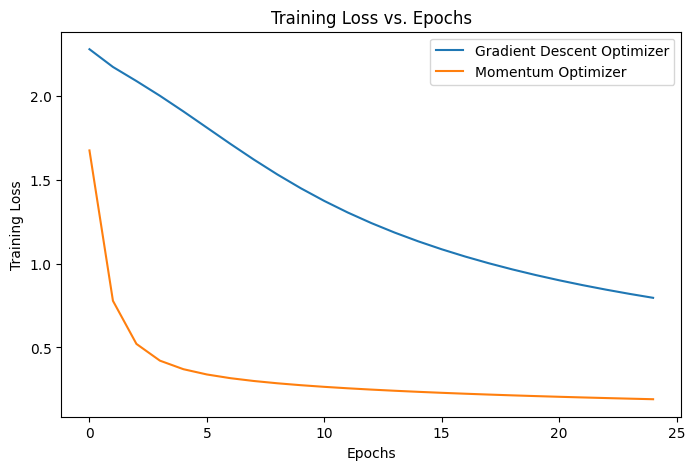

Test Accuracy (Gradient Descent Optimizer): 0.8416
Test Accuracy (Momentum Optimizer): 0.9301


In [66]:
# Plot training loss over epochs
import matplotlib.pyplot as plt

name_gd, name_mo = "Gradient Descent Optimizer", "Momentum Optimizer"
plt.figure(figsize=(8,5))
plt.plot(loss_gd, label=name_gd)
plt.plot(loss_mo, label=name_mo)
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Epochs')
plt.legend()
plt.show()

# Print final test accuracy
print(f"Test Accuracy ({name_gd}): {test_acc_gd:.4f}")
print(f"Test Accuracy ({name_mo}): {test_acc_mo:.4f}")

### Questions:

Tune the parameters (like earlier, test a few and keep track of the ones you tested) then answer the following questions:

1. Which optimizer converges faster? Justify your answer based on the training loss curves.

    `YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

    `YOUR ANSWER ENDS HERE`

2. Does momentum improve test accuracy? Why or why not?


    `YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

    `YOUR ANSWER ENDS HERE`


3. In what situations would momentum be more beneficial?

    `YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

    `YOUR ANSWER ENDS HERE`


## (Bonus) Task 3C.6: Compare MLP to CNN (10pt)

Complete an implmentation of convolutional neural network below. You will need to import/install pytorch 

You can follow this tutorial (or simply pip install torch):
https://pytorch.org/get-started/locally/


In [63]:
# install pytorch for our models
!pip3 install torch


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Warning: this might take a while to run on CPU. 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Assume these variables are already defined:
#   train_data: NumPy array of shape (N_train, 784) with values in [0, 1]
#   test_data:  NumPy array of shape (N_test, 784) with values in [0, 1]
#   train_labels: one-hot encoded labels (shape: (N_train, 10))
#   test_labels:  one-hot encoded labels (shape: (N_test, 10))

# Convert one-hot encoded labels to integer labels
train_labels_int = np.argmax(train_labels, axis=1)
test_labels_int  = np.argmax(test_labels, axis=1)

# Reshape the data from (N, 784) to (N, 1, 28, 28)
train_data_tensor = torch.from_numpy(train_data.reshape(-1, 1, 28, 28)).float()
test_data_tensor  = torch.from_numpy(test_data.reshape(-1, 1, 28, 28)).float()

# Convert labels to PyTorch tensors
train_labels_tensor = torch.from_numpy(train_labels_int).long()
test_labels_tensor  = torch.from_numpy(test_labels_int).long()

# Create DataLoaders for training and testing
batch_size = 64
train_dataset = TensorDataset(train_data_tensor, train_labels_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(test_data_tensor, test_labels_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Define a simple CNN model for MNIST.
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # First convolutional block: Conv -> ReLU -> MaxPool
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)  # TODO: Adjust parameters if needed
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Second convolutional block: Conv -> ReLU -> MaxPool
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)  # TODO: Adjust parameters if needed
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layers
        # After two pooling layers, the 28x28 image becomes 7x7 feature maps.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # TODO: Ensure dimensions match
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)  # 10 classes for MNIST

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1) 
        x = self.fc2(self.relu3(self.fc1(x)))
        return x


# Instantiate the CNN, define loss and optimizer. You can read pytorch documentation to understand these components.
#! YOUR CODE STARTS HERE

cnn_model = CNNModel()
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn_model.parameters(), lr=0.01, momentum=0.9)

#! YOUR CODE ENDS HERE


# Training Loop
num_epochs = 5
cnn_model.train()  # Set the model to training mode
print("Training CNN model...")

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        
        optimizer.zero_grad()         # Clear the gradients

        #next, you need to implement the training step including forward pass, loss computation, backward pass, and parameter update.
        # 1 start with first getting model ouptputs by passing images through cnn_model
        # 2 next you will need to use your lossfunc 
        # 3 research how to do a backward pass in pytorch (hint: it is very simple!)
        # 4 finally, you will need to update the model parameters using your optimizer (hint: also very simple!)

        #! YOUR CODE STARTS HERE

        outputs = cnn_model(images)
        loss = loss_func(outputs, labels)        

        loss.backward()                         
        optimizer.step()

        #! YOUR CODE ENDS HERE
        
        running_loss += loss.item()
        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}")
            running_loss = 0.0

print("CNN training finished!")
cnn_model.eval()  # Set the model to evaluation mode


# Evaluate the CNN on the test set.
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy of CNN: {100 * correct / total:.2f}%")


3. Play around with drawing your own numbers and compare. When you run the code, expect a small window to pop up, with `Predict` and `Clear` buttons. After you finish one prediction by drawing and hitting `Predict`, click `Clear` to draw another. 

**Which model is better? Why do you think that is?**

In [ ]:
import tkinter as tk
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageOps
import torch

class DigitDrawer:
    def __init__(self, master, nn_model, cnn_model):
        self.master = master
        self.master.title("Digit Recognition")

        self.canvas_width = 280
        self.canvas_height = 280
        self.canvas = tk.Canvas(master, width=self.canvas_width, height=self.canvas_height, bg="white")
        self.canvas.pack(padx=10, pady=10)

        # Frame for buttons
        button_frame = tk.Frame(master)
        button_frame.pack(pady=5)
        
        self.button_predict = tk.Button(button_frame, text="Predict", command=self.predict)
        self.button_predict.pack(side=tk.LEFT, padx=5)

        self.button_clear = tk.Button(button_frame, text="Clear", command=self.clear)
        self.button_clear.pack(side=tk.LEFT, padx=5)

        # Create a high-res image for smoother drawing.
        # We later downsample to 28x28 for the model.
        self.image = Image.new("L", (self.canvas_width, self.canvas_height), 255)
        self.draw = ImageDraw.Draw(self.image)

        self.canvas.bind("<B1-Motion>", self.paint)

        self.nn_model = nn_model
        self.cnn_model = cnn_model
        
    def softmax(x):
        # x is assumed to be a NumPy array
        shifted_x = x - np.max(x, axis=1, keepdims=True)  
        exp_x = np.exp(shifted_x)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)


    def paint(self, event):
        """Draw on both the canvas and the high-res PIL image."""
        # Define the brush radius
        radius = 8  
        x, y = event.x, event.y
        x1, y1 = x - radius, y - radius
        x2, y2 = x + radius, y + radius

        # Draw on the Tkinter canvas (for display)
        self.canvas.create_oval(x1, y1, x2, y2, fill="black", outline="black")
        # Draw on the high resolution PIL image (for prediction)
        self.draw.ellipse([x1, y1, x2, y2], fill="black")

    def preprocess_image(self):
        """
        Downsample the high-res image (280x280) to 28x28.
        Then normalize the pixel values to [0,1].
        """
        img_resized = self.image.resize((28, 28))
        img_inverted = ImageOps.invert(img_resized) # Invert colors: model expects black background
        img_array = np.array(img_inverted).reshape(1, 1, 28, 28) / 255.0 # Convert image to numpy array and normalize
        return img_array

    def predict(self):
        """Predict the digit using both the NN and CNN models and display the results."""
        img_array = self.preprocess_image()

        # --- NN Prediction ---
        # Use the NN's forward propagation method to get full probabilities.
        nn_probs, _ = self.nn_model.forwardprop(img_array.reshape(1, -1))
        nn_probs = nn_probs[0]  # probabilities for the single sample
        nn_prediction = np.argmax(nn_probs)

        # --- CNN Prediction ---
        self.cnn_model.eval()
        with torch.no_grad():
            img_tensor = torch.tensor(img_array, dtype=torch.float32)
            cnn_output = self.cnn_model(img_tensor)
            cnn_probs = torch.nn.functional.softmax(cnn_output, dim=1).numpy()[0]
            cnn_prediction = np.argmax(cnn_probs)

        # Create a figure to display the drawn image and the prediction probabilities
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Left subplot: the high-res drawn digit (before downsampling)
        axes[0].imshow(self.image, cmap='gray')
        axes[0].set_title("Drawn Digit")
        axes[0].axis('off')

        # Right subplot: a bar chart comparing prediction probabilities
        digits = np.arange(10)
        bar_width = 0.35
        axes[1].bar(digits - bar_width/2, nn_probs, bar_width, label='NN', color='skyblue')
        axes[1].bar(digits + bar_width/2, cnn_probs, bar_width, label='CNN', color='salmon')
        axes[1].set_xticks(digits)
        axes[1].set_xlabel("Digit")
        axes[1].set_ylabel("Probability")
        axes[1].set_title("Prediction Probabilities")
        axes[1].legend()

        plt.suptitle(f"Predictions - NN: {nn_prediction}, CNN: {cnn_prediction}", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    def clear(self):
        """Clear the canvas and reset the high-res image."""
        self.canvas.delete("all")
        self.image = Image.new("L", (self.canvas_width, self.canvas_height), 255)
        self.draw = ImageDraw.Draw(self.image)

# --------------------------
# Launch the Graphical User Interface
# --------------------------
# Ensure that 'model' (the NN) and 'cnn_model' (the CNN) are loaded before this code runs.
root = tk.Tk()
app = DigitDrawer(root, mlp_mo, cnn_model)
root.mainloop()


### Questions:

Tune the parameters (like earlier, test a few and keep track of the ones you tested) then answer the following questions:

1. Briefly explain your code for above (CNN implementation, training loop, etc.).

    `YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

    `YOUR ANSWER ENDS HERE`

2. Play around with drawing your own numbers and compare. Which model is better? Why do you think that is?


    `YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

    `YOUR ANSWER ENDS HERE`


